<div style="background:linear-gradient(135deg,#0a0a0a 0%,#1a1a2e 60%,#16213e 100%);
            padding:44px 44px 36px 44px;border-radius:16px;
            border-left:7px solid #E8002D;margin-bottom:6px;">

  <p style="color:#E8002D;font-size:.8em;letter-spacing:4px;
            text-transform:uppercase;margin:0 0 10px 0;font-family:monospace;">
    Portfolio Project · Data Analysis
  </p>
  <h1 style="color:#fff;font-size:2.6em;font-family:'Georgia',serif;
             margin:0 0 8px 0;line-height:1.2;">
    🏎️ Formula 1 Performance Analysis
  </h1>
  <h3 style="color:#b0b0b0;font-family:'Georgia',serif;
             margin:0 0 20px 0;font-weight:400;font-size:1.2em;">
    Modern Era Deep Dive &nbsp;·&nbsp; 2000–2024
  </h3>
  <p style="color:#ccc;font-size:1em;line-height:1.75;max-width:760px;margin:0 0 24px 0;">
    25 seasons of Formula 1, analysed through a production-grade data engineering pipeline.
    From the Schumacher–Ferrari dynasty to the Verstappen era — uncovering the structural
    patterns behind dominance, competitiveness, and reliability.
  </p>

  <div style="display:flex;gap:24px;flex-wrap:wrap;margin-bottom:24px;">
    <div style="background:#ffffff0d;border-radius:8px;padding:12px 20px;">
      <p style="color:#E8002D;font-size:1.5em;font-weight:bold;margin:0;">479</p>
      <p style="color:#aaa;font-size:.75em;margin:3px 0 0;text-transform:uppercase;letter-spacing:1px;">Grands Prix</p>
    </div>
    <div style="background:#ffffff0d;border-radius:8px;padding:12px 20px;">
      <p style="color:#E8002D;font-size:1.5em;font-weight:bold;margin:0;">117</p>
      <p style="color:#aaa;font-size:.75em;margin:3px 0 0;text-transform:uppercase;letter-spacing:1px;">Drivers</p>
    </div>
    <div style="background:#ffffff0d;border-radius:8px;padding:12px 20px;">
      <p style="color:#E8002D;font-size:1.5em;font-weight:bold;margin:0;">25</p>
      <p style="color:#aaa;font-size:.75em;margin:3px 0 0;text-transform:uppercase;letter-spacing:1px;">Seasons</p>
    </div>
    <div style="background:#ffffff0d;border-radius:8px;padding:12px 20px;">
      <p style="color:#E8002D;font-size:1.5em;font-weight:bold;margin:0;">10,079</p>
      <p style="color:#aaa;font-size:.75em;margin:3px 0 0;text-transform:uppercase;letter-spacing:1px;">Race Results</p>
    </div>
  </div>

  <hr style="border:none;border-top:1px solid #2a2a2a;margin:0 0 14px 0;"/>
  <p style="color:#666;font-size:.85em;margin:0;line-height:1.6;">
    <strong style="color:#888;">Source:</strong> Ergast Motor Racing API &nbsp;·&nbsp;
    <strong style="color:#888;">Stack:</strong> Python · pandas · matplotlib · seaborn &nbsp;·&nbsp;
    <strong style="color:#888;">Scope:</strong> 2000–2024
  </p>
</div>

## 📋 Table of Contents

1. [Introduction](#1-introduction)
2. [Data Overview](#2-data-overview)
3. [Data Preparation](#3-data-preparation)
4. [Analysis](#4-analysis)
   - [4.1 Who Scored the Most? Driver Career Points](#41-who-scored-the-most-driver-career-points)
   - [4.2 Explosiveness vs Consistency: Win Rate vs Podium Rate](#42-explosiveness-vs-consistency-win-rate-vs-podium-rate)
   - [4.3 Was F1 Actually Competitive? Championship HHI Index](#43-was-f1-actually-competitive-championship-hhi-index)
   - [4.4 The Rise and Fall of Constructor Dynasties](#44-the-rise-and-fall-of-constructor-dynasties)
   - [4.5 Can You Win Without Finishing? Reliability vs Performance](#45-can-you-win-without-finishing-reliability-vs-performance)
   - [4.6 How Close Were the Title Fights?](#46-how-close-were-the-title-fights)
   - [4.7 Which Teams Built the Most Reliable Cars?](#47-which-teams-built-the-most-reliable-cars)
5. [Conclusions & Strategic Takeaways](#5-conclusions--strategic-takeaways)
6. [Executive Summary](#6-executive-summary)

---
## 1. Introduction

Formula 1 is a sport where engineering precision, driver skill, and strategic decision-making converge at speeds exceeding 350 km/h. Beyond the spectacle, it generates one of the richest performance datasets in professional sports — race results, qualifying times, pit-stop durations, lap-by-lap records — across seven decades of competition.

This notebook is built to answer questions that go beyond *"who won the most races?"* and into the structural dynamics of performance.

| # | Question | Analytical Approach |
|---|---|---|
| Q1 | Who are the greatest drivers of the modern era? | Career-level performance metrics |
| Q2 | What separates elite drivers from very good ones? | Multidimensional rate comparison |
| Q3 | Was championship competition as fierce as it felt? | HHI dominance measurement |
| Q4 | Which teams dominated, and when did power shift? | Constructor time-series analysis |
| Q5 | Does finishing races matter as much as going fast? | Reliability–performance trade-off |
| Q6 | How close were the real title fights? | Margin-of-victory decomposition |
| Q7 | Which teams built the most reliable cars? | Cross-season engineering quality |

---

### Scope & Data Foundation

| Dimension | Detail |
|---|---|
| **Era** | 2000–2024 (modern Formula 1) |
| **Races** | 479 Grands Prix across 38 circuits |
| **Drivers** | 117 (minimum 5 race starts) |
| **Source** | Ergast Motor Racing API — 14 raw CSV tables |

All figures are generated from **four analytical marts** produced by a modular data engineering pipeline:
`driver_performance_mart` · `team_performance_mart` · `season_trends_mart` · `fact_race_results`

> **⚠️ Points inflation caveat:** F1 changed its scoring system in 2003 and 2010. Raw career points are not directly comparable across eras. Throughout this analysis, *per-race metrics* (win rate, podium rate, points/race) are used alongside absolutes to maintain analytical integrity.

---
## 2. Data Overview

A rigorous analyst inspects data before drawing conclusions from it. In this section we examine the structure, shape, and distribution of all four marts — confirming the pipeline produced what we expect and building intuition before any chart is drawn.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import matplotlib.patheffects as pe
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from pathlib import Path

%matplotlib inline
plt.rcParams['figure.dpi'] = 130
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ Libraries loaded.")
print(f"   pandas {pd.__version__}  |  matplotlib {plt.matplotlib.__version__}  |  seaborn {sns.__version__}")

✅ Libraries loaded.
   pandas 2.2.3  |  matplotlib 3.10.0  |  seaborn 0.13.2


In [2]:
BASE = Path('../outputs')

drivers = pd.read_csv(BASE / 'driver_performance_mart.csv',  parse_dates=['dob'])
teams   = pd.read_csv(BASE / 'team_performance_mart.csv')
seasons = pd.read_csv(BASE / 'season_trends_mart.csv')
facts   = pd.read_csv(BASE / 'fact_race_results.csv',        parse_dates=['date'])

print("📦 Marts loaded:")
print(f"   driver_performance_mart : {drivers.shape[0]:>4} rows × {drivers.shape[1]} cols")
print(f"   team_performance_mart   : {teams.shape[0]:>4} rows × {teams.shape[1]} cols")
print(f"   season_trends_mart      : {seasons.shape[0]:>4} rows × {seasons.shape[1]} cols")
print(f"   fact_race_results       : {facts.shape[0]:>5} rows × {facts.shape[1]} cols")

📦 Marts loaded:
   driver_performance_mart :  117 rows × 22 cols
   team_performance_mart   :  266 rows × 17 cols
   season_trends_mart      :   25 rows × 10 cols
   fact_race_results       : 10079 rows × 23 cols


### 2.1 Driver Performance Mart — 117 rows × 22 cols

One row per driver. Key metrics: `races_entered`, `wins`, `podiums`, `win_rate_pct`, `podium_rate_pct`, `dnf_rate_pct`, `points_per_race`, `avg_grid`, `avg_finish`, `best_season_points`.

> Top 8 drivers shown — sorted by total career points.

In [3]:
drivers.head(8)

,driver_id,full_name,code,nationality,dob,first_season,last_season,seasons_active,races_entered,wins,podiums,dnf_count,points_total,best_season_points,points_per_race,win_rate_pct,podium_rate_pct,dnf_rate_pct,avg_grid,avg_finish,avg_qualifying_ms,avg_pit_stop_s
0,1,Lewis Hamilton,HAM,British,1985-01-07,2007,2024,18,356,105,202,30,4820.50,413.00,13.54,29.49,56.74,8.43,4.30,3.64,86752.20,23.52
1,20,Sebastian Vettel,VET,German,1987-07-03,2007,2022,16,300,53,122,38,3098.00,397.00,10.33,17.67,40.67,12.67,6.27,5.28,87581.90,23.73
2,830,Max Verstappen,VER,Dutch,1997-09-30,2015,2024,10,209,63,112,30,2912.50,530.00,13.94,30.14,53.59,14.35,4.96,3.55,85000.70,24.22
3,4,Fernando Alonso,ALO,Spanish,1981-07-29,2001,2024,21,404,32,106,70,2329.00,278.00,5.76,7.92,26.24,17.33,8.58,6.46,87067.70,23.82
4,8,Kimi Räikkönen,RAI,Finnish,1979-10-17,2001,2021,19,352,21,103,67,1873.00,251.00,5.32,5.97,29.26,19.03,7.53,6.24,86663.10,24.54
5,822,Valtteri Bottas,BOT,Finnish,1989-08-28,2013,2024,12,247,10,67,27,1788.00,326.00,7.24,4.05,27.13,10.93,7.86,7.83,86700.60,24.86
6,3,Nico Rosberg,ROS,German,1985-06-27,2006,2016,11,206,23,57,29,1594.50,385.00,7.74,11.16,27.67,14.08,6.90,6.36,88821.60,23.27
7,815,Sergio Pérez,PER,Mexican,1990-01-26,2011,2024,14,283,6,39,32,1585.00,291.00,5.60,2.12,13.78,11.31,9.44,8.01,87681.10,24.11


### 2.2 Team Performance Mart — 266 rows × 17 cols

One row per constructor per season. Enables longitudinal team analysis. Key metrics include `wins`, `reliability_pct`, `wcc_position`, `points_per_race`.

> Showing 2023 — the most statistically extreme season in the dataset.

In [4]:
teams[teams['year'] == 2023].reset_index(drop=True)

,constructor_id,name,nationality,year,races,entries,wins,podiums,poles,dnf_count,drivers_used,points_total,points_per_race,wcc_position,win_rate_pct,podium_rate_pct,reliability_pct
0,9,Red Bull,Austrian,2023,22,44,21,30,14,2,2,790.00,35.91,1,47.73,68.18,95.45
1,131,Mercedes,German,2023,22,44,0,8,1,5,2,374.00,17.00,2,0.00,18.18,88.64
2,6,Ferrari,Italian,2023,22,44,1,9,7,7,2,363.00,16.50,3,2.27,20.45,84.09
3,1,McLaren,British,2023,22,44,0,9,0,4,2,266.00,12.09,4,0.00,20.45,90.91
4,117,Aston Martin,British,2023,22,44,0,8,0,6,2,266.00,12.09,5,0.00,18.18,86.36
5,214,Alpine F1 Team,French,2023,22,44,0,2,0,7,2,110.00,5.00,6,0.00,4.55,84.09
6,3,Williams,British,2023,22,44,0,0,0,9,2,26.00,1.18,7,0.00,0.00,79.55
7,213,AlphaTauri,Italian,2023,22,44,0,0,0,3,4,22.00,1.00,8,0.00,0.00,93.18
8,51,Alfa Romeo,Swiss,2023,22,44,0,0,0,6,2,16.00,0.73,9,0.00,0.00,86.36
9,210,Haas F1 Team,American,2023,22,44,0,0,0,5,2,9.00,0.41,10,0.00,0.00,88.64


### 2.3 Season Trends Mart — 25 rows × 10 cols

One row per season. Contains WDC/WCC champions, points, `dominance_hhi` (Herfindahl-Hirschman Index of race win share), and `wdc_margin_pts` (points gap between P1 and P2).

In [5]:
seasons

,year,total_races,total_drivers,total_constructors,wdc_driver,wdc_points,wcc_team,wcc_points,dominance_hhi,wdc_margin_pts
0,2000,17,23,11,Michael Schumacher,108.00,Ferrari,170.00,0.37,19.00
1,2001,17,26,11,Michael Schumacher,123.00,Ferrari,179.00,0.34,58.00
2,2002,17,23,11,Michael Schumacher,144.00,Ferrari,221.00,0.48,67.00
3,2003,16,24,10,Michael Schumacher,93.00,Ferrari,158.00,0.20,2.00
4,2004,18,25,10,Michael Schumacher,148.00,Ferrari,262.00,0.54,34.00
5,2005,19,27,10,Fernando Alonso,133.00,Renault,191.00,0.30,21.00
6,2006,18,27,12,Fernando Alonso,134.00,Renault,206.00,0.32,13.00
7,2007,17,26,11,Kimi Räikkönen,110.00,Ferrari,204.00,0.27,1.00
8,2008,18,22,11,Lewis Hamilton,98.00,Ferrari,172.00,0.22,1.00
9,2009,17,25,10,Jenson Button,95.00,Brawn,172.00,0.22,11.00


### 2.4 Descriptive Statistics

Key distributions — note that `win_rate_pct` will be highly right-skewed: the mean sits below 3% because only a handful of drivers have ever won more than 10% of their starts.

In [6]:
print("── Driver Mart ──")
display(drivers[['races_entered','wins','podiums','points_total',
                  'win_rate_pct','podium_rate_pct','dnf_rate_pct',
                  'points_per_race','avg_grid','avg_finish']].describe().round(2))

print("\n── Season Mart ──")
display(seasons[['total_races','total_drivers','wdc_points',
                  'dominance_hhi','wdc_margin_pts']].describe().round(2))

── Driver Mart ──


,races_entered,wins,podiums,points_total,win_rate_pct,podium_rate_pct,dnf_rate_pct,points_per_race,avg_grid,avg_finish
count,117.00,117.00,117.00,117.00,117.00,117.00,117.00,117.00,117.00,117.00
mean,85.99,4.09,12.28,316.77,1.87,6.03,26.57,1.62,14.06,11.48
std,88.38,13.78,30.30,720.84,5.47,11.98,14.33,2.73,4.35,3.55
min,5.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.53,3.12
25%,21.00,0.00,0.00,1.00,0.00,0.00,15.79,0.05,11.33,9.37
50%,46.00,0.00,0.00,18.00,0.00,0.00,23.71,0.37,14.53,11.84
75%,128.00,1.00,4.00,238.00,0.48,4.76,35.00,2.00,17.17,13.92
max,404.00,105.00,202.00,4820.50,31.11,56.74,68.97,13.94,23.00,18.22



── Season Mart ──


,total_races,total_drivers,wdc_points,dominance_hhi,wdc_margin_pts
count,25.00,25.00,25.00,25.00,25.00
mean,19.16,23.92,282.18,0.36,59.76
std,2.06,2.20,147.73,0.13,67.70
min,16.00,20.00,93.00,0.16,1.00
25%,17.00,22.00,133.00,0.27,8.00
50%,19.00,24.00,347.00,0.35,46.00
75%,21.00,25.00,395.50,0.43,87.00
max,24.00,28.00,575.00,0.76,290.00


---
## 3. Data Preparation

The pipeline handled null replacement, type casting, column standardisation (camelCase → snake_case), and deduplication. Here we define the visual theme, create analysis subsets, and derive labelling columns.

> **Minimum sample size rule:** Rate metrics (win rate, DNF rate) require adequate sample sizes to be meaningful. Thresholds used: **50+ starts** for performance rates, **30+ starts** for reliability analysis.

In [7]:
# ── Visual theme ─────────────────────────────────────────────────────────────
F1_DARK, F1_GREY, F1_SILVER = '#0A0A0A', '#1C1C1C', '#C0C0C0'
F1_WHITE, F1_RED, ACCENT     = '#F5F5F5', '#E8002D', '#FF8000'

TEAM_PALETTE = {
    'Ferrari': '#DC0000', 'McLaren': '#FF8000', 'Mercedes': '#00D2BE',
    'Red Bull': '#3671C6', 'Renault': '#F5E642', 'Alpine F1 Team': '#0093CC',
    'Williams': '#005AFF', 'Aston Martin': '#006F62', 'Brawn': '#B0FF00',
    'Lotus F1 Team': '#FFB800', 'BAR': '#C8102E', 'Toyota': '#CC0000',
}

NAT_PALETTE = {
    'British': '#00247D', 'German': '#FFCE00', 'Finnish': '#003580',
    'Spanish': '#AA151B', 'Dutch': '#FF6600', 'Australian': '#00843D',
    'Brazilian': '#009C3B', 'Mexican': '#006847', 'French': '#0055A4',
    'Monegasque': '#CE1126', 'Austrian': '#ED2939', 'Danish': '#C60C30',
}

def style_ax(ax, title='', xlabel='', ylabel='', grid='y'):
    ax.set_facecolor(F1_GREY)
    ax.set_title(title,   color=F1_WHITE,  fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel(xlabel, color=F1_SILVER, fontsize=10)
    ax.set_ylabel(ylabel, color=F1_SILVER, fontsize=10)
    ax.tick_params(colors=F1_SILVER, labelsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor('#333333')
    if grid:
        ax.grid(axis=grid, color='#2E2E2E', linewidth=0.8, linestyle='--')
    ax.set_axisbelow(True)

print("✅ Theme configured.")

✅ Theme configured.


In [8]:
# ── Derived columns & analysis subsets ───────────────────────────────────────
drivers['surname'] = drivers['full_name'].str.split().str[-1]

d_50plus = drivers[drivers['races_entered'] >= 50].copy()
d_30plus = drivers[drivers['races_entered'] >= 30].copy()
d_30plus['surname'] = d_30plus['full_name'].str.split().str[-1]

top5_teams = (
    teams.groupby('name')['points_total']
    .sum().nlargest(5).index.tolist()
)

print(f"Drivers 50+ starts : {len(d_50plus)}")
print(f"Drivers 30+ starts : {len(d_30plus)}")
print(f"Top-5 constructors : {top5_teams}")

Drivers 50+ starts : 57
Drivers 30+ starts : 77
Top-5 constructors : ['Ferrari', 'Red Bull', 'Mercedes', 'McLaren', 'Williams']


---
## 4. Analysis

Seven analyses, each structured as: **context → what/why/expect → chart → insight**.
Questions build progressively — from driver rankings, to performance archetypes, to championship dynamics, to engineering quality.

---
### 4.1 Who Scored the Most? Driver Career Points

**What:** Total championship points per driver across the 2000–2024 era — top 15 shown.

**Why it matters:** Career points capture sustained excellence across machinery, seasons, and regulation changes. They are the most comprehensive single-number summary of a modern-era driver's impact.

**Hypothesis:** Hamilton leads by a substantial margin from 7 World Championships. A visible drop-off after the top 4–5 drivers, reflecting how few have had sustained access to race-winning machinery.

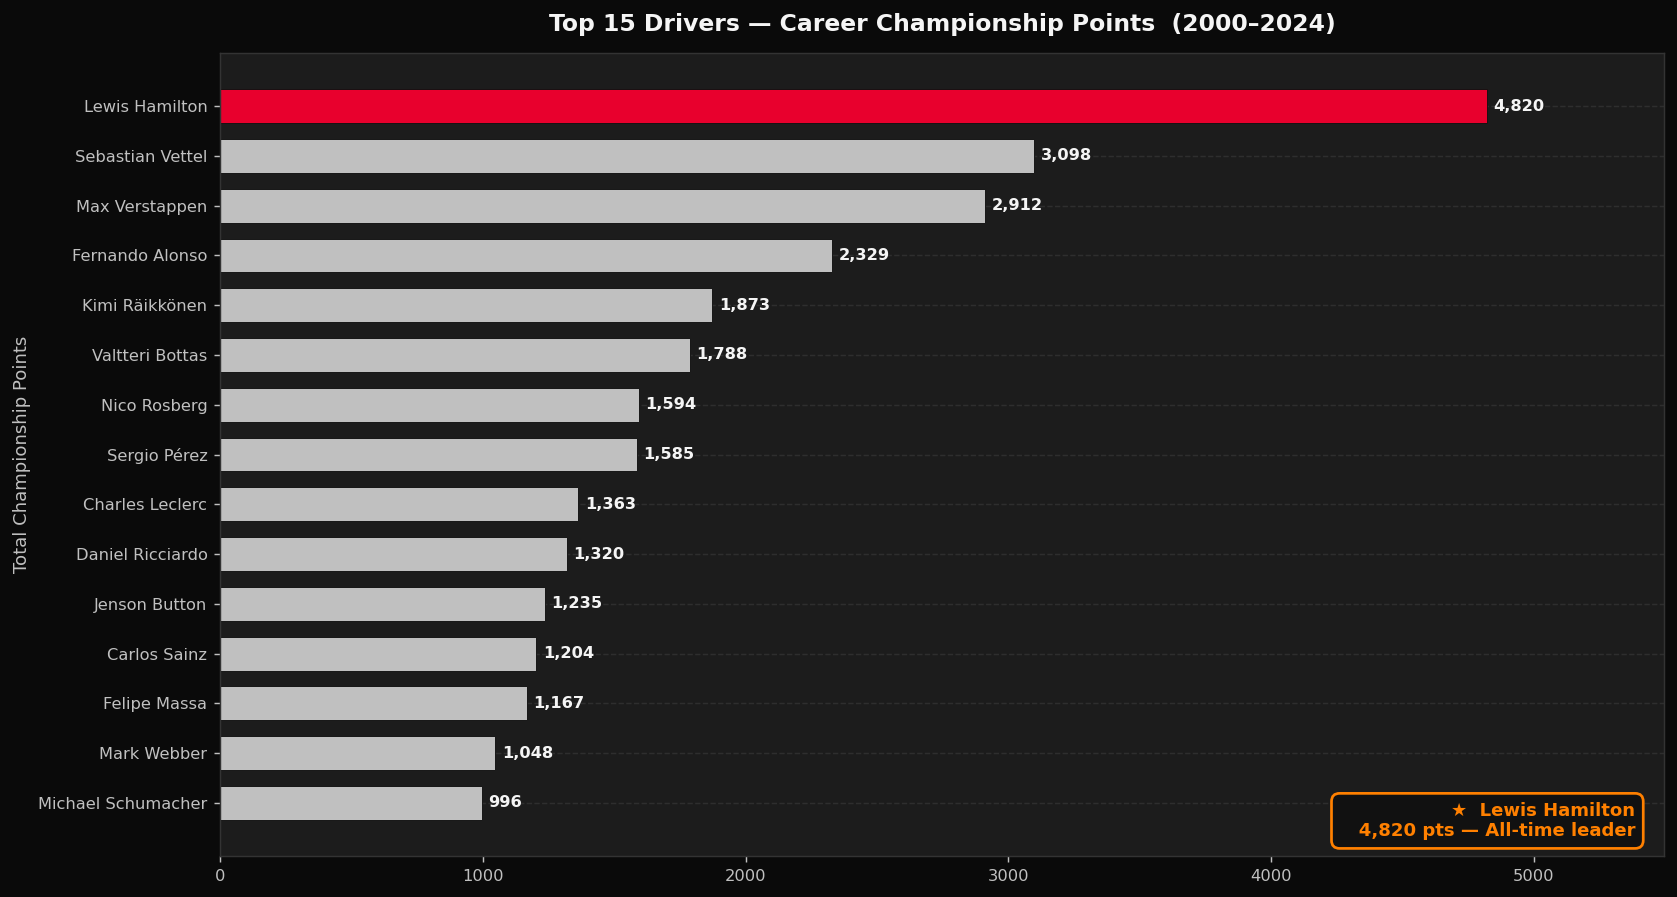

In [9]:
top15 = drivers.head(15).copy()

fig, ax = plt.subplots(figsize=(13, 7), facecolor=F1_DARK)
style_ax(ax, title='Top 15 Drivers — Career Championship Points  (2000–2024)',
         ylabel='Total Championship Points')

bar_colors = [F1_RED if i == 0 else F1_SILVER for i in range(len(top15))]
bars = ax.barh(top15['full_name'][::-1], top15['points_total'][::-1],
               color=bar_colors[::-1], height=0.68, edgecolor='#111', linewidth=0.5)

for bar, pts in zip(bars, top15['points_total'][::-1]):
    ax.text(bar.get_width() + 25, bar.get_y() + bar.get_height() / 2,
            f'{pts:,.0f}', va='center', color=F1_WHITE, fontsize=9, fontweight='bold')

ax.set_xlim(0, top15['points_total'].max() * 1.14)
ax.text(0.98, 0.02, '★  Lewis Hamilton\n   4,820 pts — All-time leader',
        transform=ax.transAxes, ha='right', va='bottom',
        color=ACCENT, fontsize=10, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.45', facecolor='#111', edgecolor=ACCENT, linewidth=1.5))

fig.patch.set_facecolor(F1_DARK)
plt.tight_layout()
plt.show()

**📊 Insight**

Hamilton's **4,820 points** across 356 starts confirms statistical supremacy — but the more interesting finding is the *rate* comparison: Verstappen scores **13.9 pts/race** vs Hamilton's **13.5**, with a near-identical win rate (30.1% vs 29.5%) in roughly half the career length. Raw totals flatter longevity; per-race metrics reveal near-parity.

**Vettel's 3,098 points** tells a tale of two careers: dominant through Red Bull's four-title run (2010–2013), then largely irrelevant once the hybrid era began. His Ferrari and Aston Martin years added little.

**Alonso in 4th** is the most analytically interesting position on this chart. He scored the vast majority of his points without a championship-calibre car — extracting maximum performance from machinery that a lesser driver would have scored far less from.

---
### 4.2 Explosiveness vs Consistency: Win Rate vs Podium Rate

**What:** Scatter of win rate (y) vs podium rate (x) for drivers with 50+ starts. Bubble size = races entered; colour = points per race.

**Why it matters:** Two drivers with identical points totals may be completely different performers — one an all-or-nothing winner, the other a relentless accumulator. This chart separates performance *archetype* from performance *volume*.

**Hypothesis:** Hamilton and Verstappen top-right (elite on both dimensions). Alonso and Räikkönen mid-right (high podium rate, lower win rate — great drivers, inferior cars). Schumacher closer to the diagonal (win-or-retire profile).

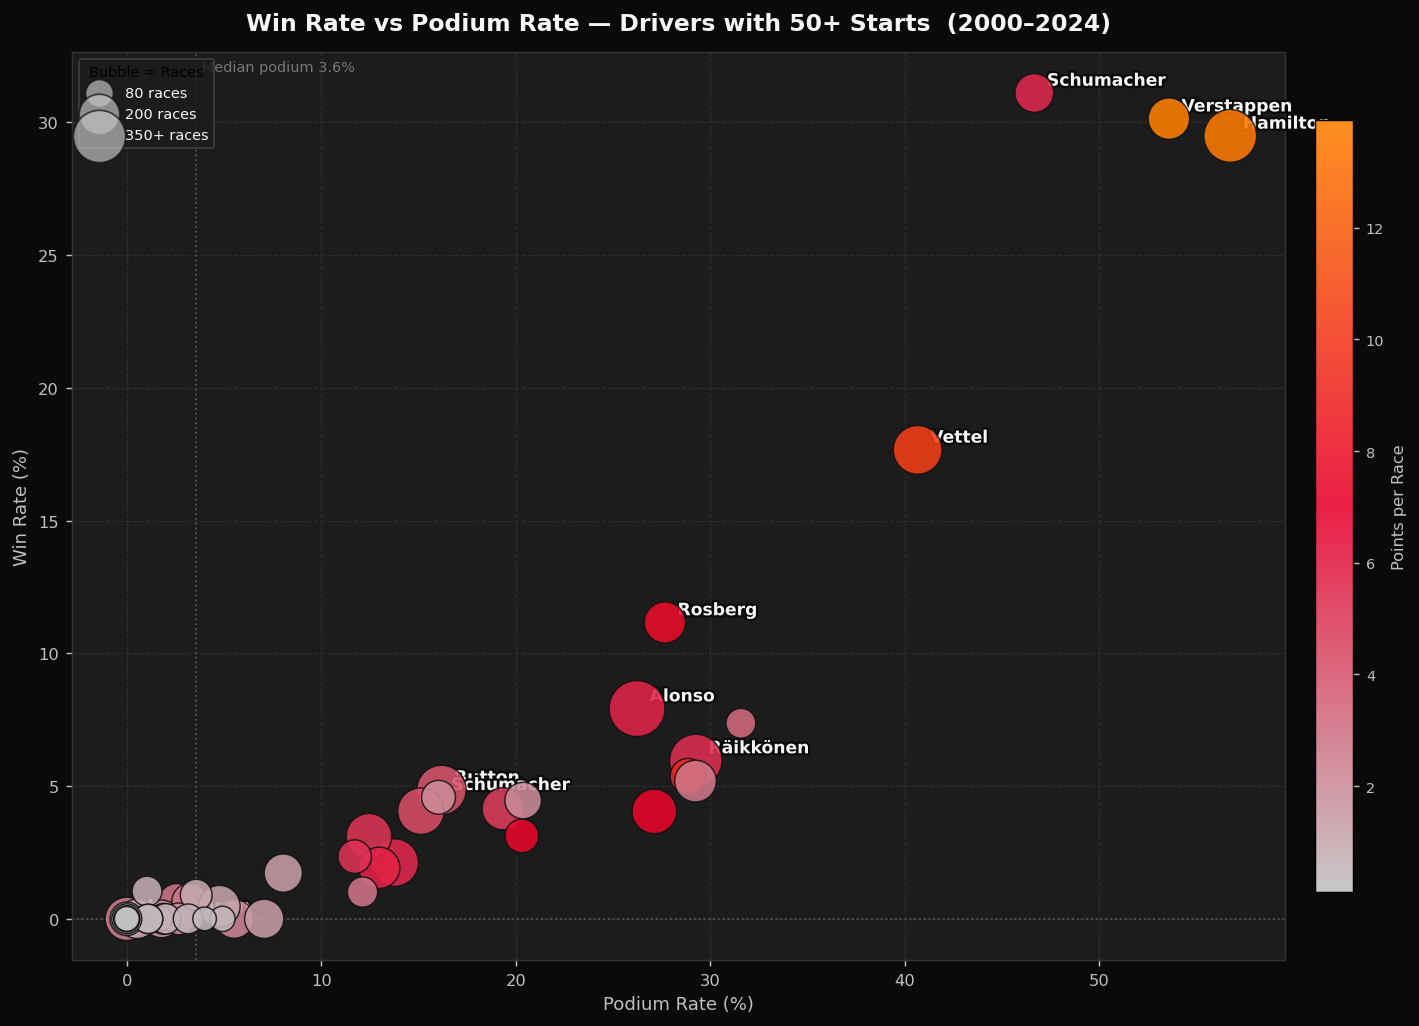

In [10]:
fig, ax = plt.subplots(figsize=(12, 8), facecolor=F1_DARK)
style_ax(ax, title='Win Rate vs Podium Rate — Drivers with 50+ Starts  (2000–2024)',
         xlabel='Podium Rate (%)', ylabel='Win Rate (%)', grid=None)
ax.grid(color='#2E2E2E', linewidth=0.7, linestyle='--')

sizes = (d_50plus['races_entered'] / d_50plus['races_entered'].max() * 900) + 60
cmap  = LinearSegmentedColormap.from_list('f1', [F1_SILVER, F1_RED, ACCENT])

sc = ax.scatter(
    d_50plus['podium_rate_pct'], d_50plus['win_rate_pct'],
    s=sizes, c=d_50plus['points_per_race'],
    cmap=cmap, alpha=0.88, edgecolors='#111', linewidths=0.8, zorder=5
)

highlight = ['Hamilton', 'Verstappen', 'Vettel', 'Schumacher',
             'Alonso', 'Räikkönen', 'Rosberg', 'Button']
for _, row in d_50plus.iterrows():
    if row['surname'] in highlight:
        ax.annotate(row['surname'],
                    xy=(row['podium_rate_pct'], row['win_rate_pct']),
                    xytext=(7, 4), textcoords='offset points',
                    color=F1_WHITE, fontsize=9.5, fontweight='bold',
                    path_effects=[pe.withStroke(linewidth=2.5, foreground=F1_DARK)])

med_pod = d_50plus['podium_rate_pct'].median()
med_win = d_50plus['win_rate_pct'].median()
ax.axvline(med_pod, color='#555', lw=1, ls=':')
ax.axhline(med_win, color='#555', lw=1, ls=':')
ax.text(med_pod + 0.3, ax.get_ylim()[1] * 0.99,
        f'Median podium {med_pod:.1f}%', color='#777', fontsize=8, va='top')

cbar = fig.colorbar(sc, ax=ax, pad=0.02, shrink=0.85)
cbar.set_label('Points per Race', color=F1_SILVER, fontsize=9)
cbar.ax.yaxis.set_tick_params(color=F1_SILVER)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color=F1_SILVER, fontsize=8)

for n, lbl in [(80, '80 races'), (200, '200 races'), (350, '350+ races')]:
    s = (n / d_50plus['races_entered'].max() * 900) + 60
    ax.scatter([], [], s=s, c=F1_SILVER, alpha=0.7, label=lbl, edgecolors='#111')
ax.legend(title='Bubble = Races', facecolor=F1_GREY, edgecolor='#444',
          labelcolor=F1_WHITE, fontsize=8, title_fontsize=8, loc='upper left')

fig.patch.set_facecolor(F1_DARK)
plt.tight_layout()
plt.show()

**📊 Insight**

Three distinct performance tiers emerge clearly.

**Elite (top-right):** Hamilton and Verstappen both exceed 50% podium rate and 15% win rate — a zone almost no other driver in the dataset reaches. Verstappen's marginally higher win rate (~30.1% vs 29.5%) at comparable podium rates suggests a slightly more ruthless conversion of opportunities.

**Aspirational (mid-right):** Vettel, Rosberg, and Schumacher cluster in the 30–50% podium range. Schumacher's position is structurally closer to the diagonal — his podium rate is lower relative to his win rate, consistent with his win-or-retire driving philosophy.

**Consistent performers (bottom-right):** Alonso, Räikkönen, and Button had strong podium rates but lower win rates — always competitive, but rarely in machinery that allowed outright victories. Alonso's podium rate is comparable to Vettel's; his win rate is less than half. That gap is the data's most precise summary of a career spent overperforming inferior cars.

---
### 4.3 Was F1 Actually Competitive? Championship HHI Index

**What:** The Herfindahl-Hirschman Index (HHI) applied to race win share per season — a tool borrowed from economics to measure market concentration — overlaid with WDC points margin (right axis).

`HHI = Σ(driver_win_share²)` · 1.0 = one driver wins everything · ~0.05 = perfectly distributed

**Why it matters:** The HHI captures *structural* competitiveness — whether a champion won because they were in a class of their own, or because they edged out multiple rivals on equal machinery.

**Hypothesis:** Dominance spikes at 2002–2004 (Schumacher), 2011/2013 (Vettel), 2023 (Verstappen). The 2008–2012 window should be the lowest HHI stretch — the most genuinely competitive era in modern F1.

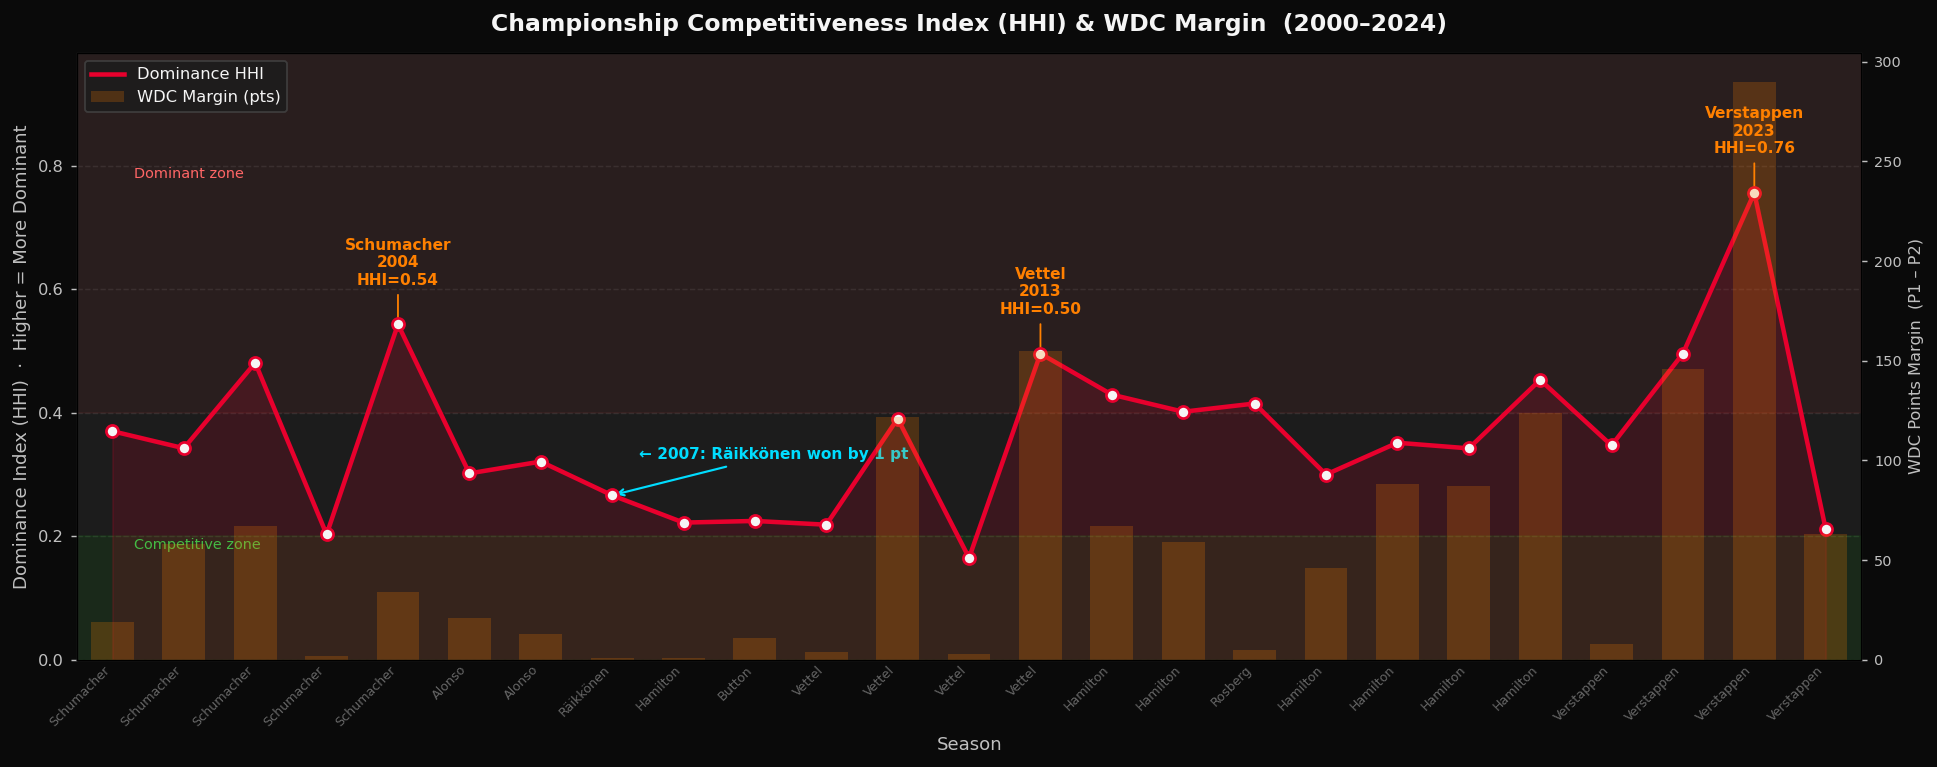

In [11]:
fig, ax1 = plt.subplots(figsize=(15, 6), facecolor=F1_DARK)
style_ax(ax1,
         title='Championship Competitiveness Index (HHI) & WDC Margin  (2000–2024)',
         xlabel='Season', ylabel='Dominance Index (HHI)  ·  Higher = More Dominant')

years, hhi = seasons['year'], seasons['dominance_hhi']

ax1.fill_between(years, hhi, alpha=0.15, color=F1_RED)
ax1.plot(years, hhi, color=F1_RED, lw=2.5, zorder=5, label='Dominance HHI')
ax1.scatter(years, hhi, color=F1_WHITE, s=45, zorder=6, edgecolors=F1_RED, linewidths=1.5)

ax1.axhspan(0.00, 0.20, alpha=0.06, color='#00FF00')
ax1.axhspan(0.40, 1.00, alpha=0.06, color='#FF4444')
ax1.text(2000.3, 0.18, 'Competitive zone', color='#44BB44', fontsize=8)
ax1.text(2000.3, 0.78, 'Dominant zone',    color='#FF6666', fontsize=8)

ax2 = ax1.twinx()
ax2.set_facecolor(F1_GREY)
ax2.bar(years, seasons['wdc_margin_pts'], alpha=0.22, color=ACCENT,
        width=0.6, label='WDC Margin (pts)')
ax2.set_ylabel('WDC Points Margin  (P1 – P2)', color=F1_SILVER, fontsize=9)
ax2.tick_params(colors=F1_SILVER, labelsize=8)

for year in [2004, 2013, 2023]:
    row = seasons[seasons['year'] == year].iloc[0]
    ax1.annotate(
        f"{row['wdc_driver'].split()[-1]}\n{year}\nHHI={row['dominance_hhi']:.2f}",
        xy=(row['year'], row['dominance_hhi']),
        xytext=(0, 22), textcoords='offset points', ha='center',
        color=ACCENT, fontsize=8.5, fontweight='bold',
        arrowprops=dict(arrowstyle='-', color=ACCENT, lw=1)
    )

row_tight = seasons.loc[seasons['wdc_margin_pts'].idxmin()]
ax1.annotate(
    f"← {int(row_tight['year'])}: {row_tight['wdc_driver'].split()[-1]} won by {row_tight['wdc_margin_pts']:.0f} pt",
    xy=(row_tight['year'], row_tight['dominance_hhi']),
    xytext=(15, 20), textcoords='offset points',
    color='#00DDFF', fontsize=8.5, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#00DDFF', lw=1.2)
)

# FIX: champion labels as proper x-tick labels — eliminates blank space below chart
ax1.set_xticks(seasons['year'])
ax1.set_xticklabels(
    [row['wdc_driver'].split()[-1] for _, row in seasons.iterrows()],
    rotation=45, ha='right', color='#666', fontsize=7
)
ax1.tick_params(axis='x', length=0, pad=2)

ax1.set_xlim(1999.5, 2024.5)
ax1.set_ylim(0, hhi.max() * 1.30)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           facecolor=F1_GREY, edgecolor='#444', labelcolor=F1_WHITE,
           fontsize=9, loc='upper left')

fig.patch.set_facecolor(F1_DARK)
plt.tight_layout()
plt.show()

**📊 Insight**

**2023 was the most statistically dominant season since records began.** Verstappen's HHI of **0.76** — winning 21 of 22 races — dwarfs even Schumacher's most extreme year (2004, HHI = 0.54). By the standard used in antitrust economics, 2023 F1 was a monopoly.

**The Schumacher era shows a build-then-collapse pattern.** The 2000–2004 ramp-up reflects Ferrari finding and maximising a technical edge, followed by an almost vertical drop when regulations changed in 2005. This is the archetype every subsequent dynasty has followed.

**2012 is the data's competitive outlier (HHI = 0.165):** seven different winners in the first seven races; championship decided on the final lap of the final race. The most genuinely multi-winner season in the modern era — and the hardest for any single-team narrative to survive intact.

**A structural trend worth noting:** dominance peaks are getting higher — 0.54 (Schumacher), 0.50 (Vettel), 0.76 (Verstappen). Whether this reflects cost-cap consolidation or Red Bull's specific technical advantage in 2023 is a question the next few seasons will answer.

---
### 4.4 The Rise and Fall of Constructor Dynasties

**What:** Championship points per season for the top 5 constructors by cumulative modern-era points (Ferrari, Red Bull, Mercedes, McLaren, Williams), with era bands.

**Why it matters:** Constructors supply both cars — their points reflect engineering excellence more directly than driver talent. Tracking over time shows exactly when technical power shifted and how quickly it can collapse.

**Hypothesis:** Ferrari high 2000–2004, multi-team competition 2005–2009, Red Bull explosion 2010–2013, Mercedes dominance 2014–2021, Red Bull return 2022–2023.

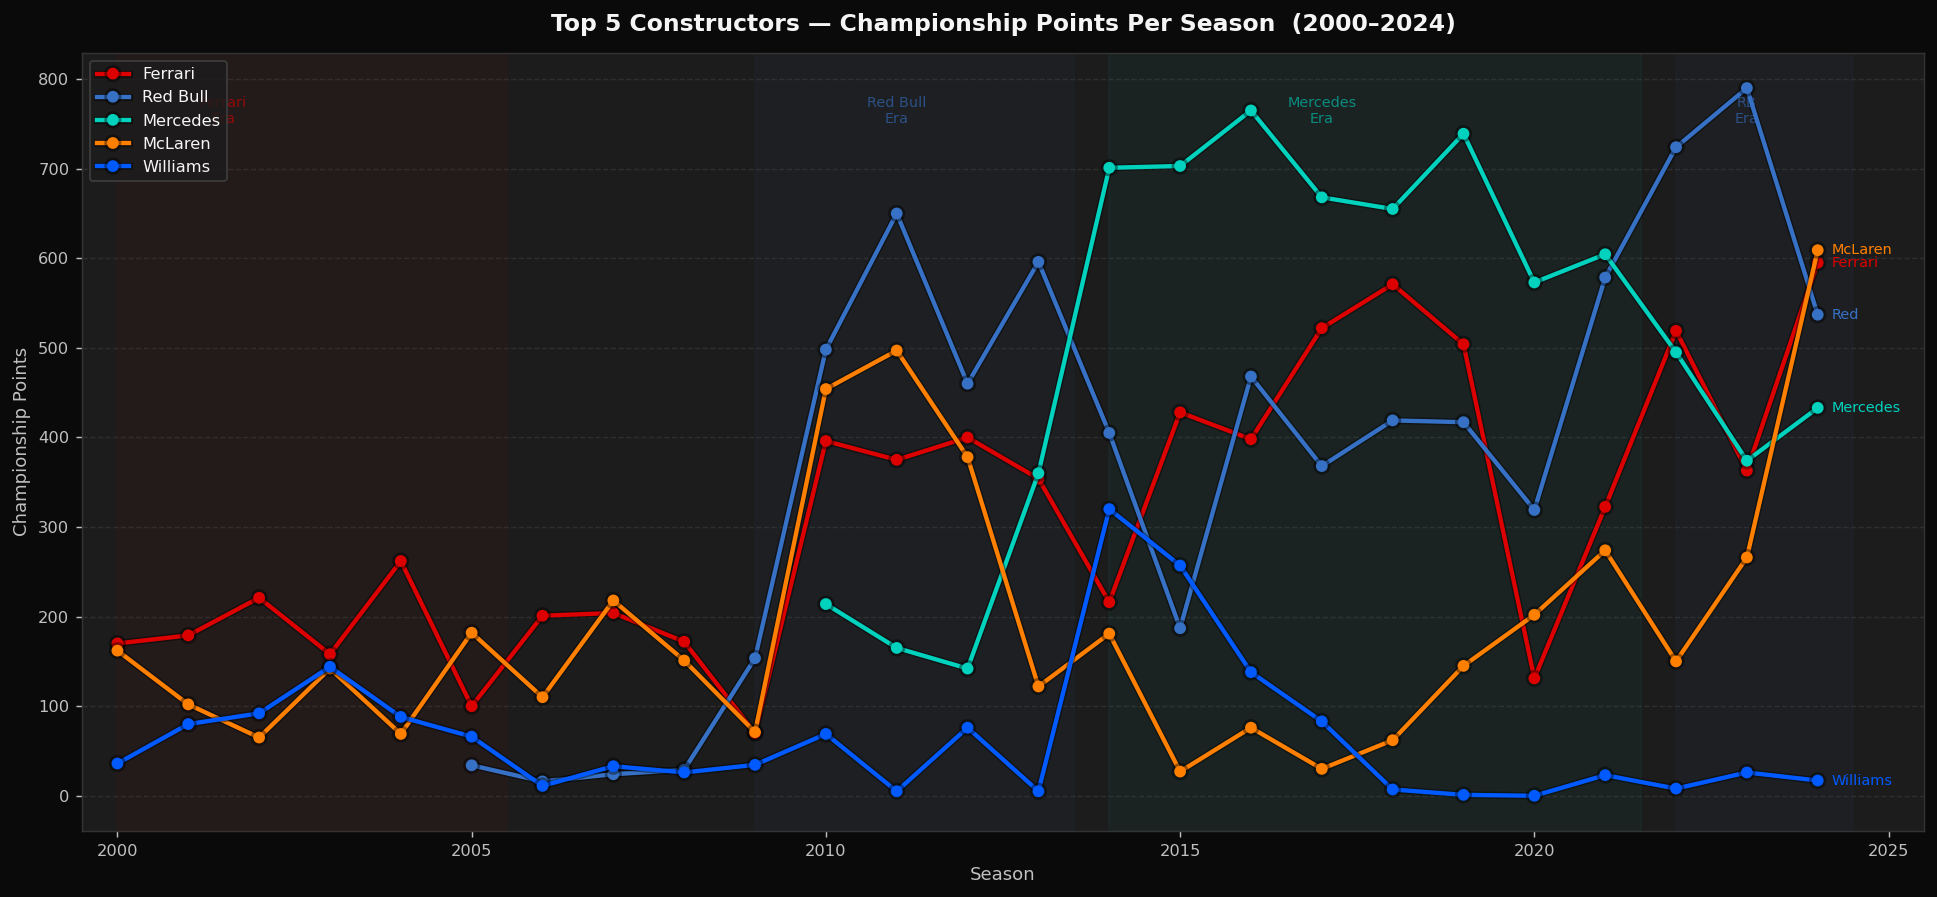

In [12]:
fig, ax = plt.subplots(figsize=(15, 7), facecolor=F1_DARK)
style_ax(ax, title='Top 5 Constructors — Championship Points Per Season  (2000–2024)',
         xlabel='Season', ylabel='Championship Points')

for team in top5_teams:
    td    = teams[teams['name'] == team].sort_values('year')
    color = TEAM_PALETTE.get(team, F1_SILVER)
    ax.plot(td['year'], td['points_total'], marker='o', lw=2.4, markersize=5.5,
            label=team, color=color,
            path_effects=[pe.withStroke(linewidth=4, foreground='#00000066')])
    last = td.iloc[-1]
    ax.text(last['year'] + 0.2, last['points_total'],
            team.split()[0], color=color, fontsize=8, va='center')

ax.axvspan(2000, 2005.5, alpha=0.04, color='#DC0000')
ax.axvspan(2009, 2013.5, alpha=0.04, color='#3671C6')
ax.axvspan(2014, 2021.5, alpha=0.04, color='#00D2BE')
ax.axvspan(2022, 2024.5, alpha=0.04, color='#3671C6')

era_y = teams['points_total'].max() * 0.95
ax.text(2001.5, era_y, 'Ferrari\nEra',   color='#DC000099', fontsize=8, ha='center')
ax.text(2011,   era_y, 'Red Bull\nEra',  color='#3671C699', fontsize=8, ha='center')
ax.text(2017,   era_y, 'Mercedes\nEra', color='#00D2BE99', fontsize=8, ha='center')
ax.text(2023,   era_y, 'RB\nEra',       color='#3671C699', fontsize=8, ha='center')

ax.set_xlim(1999.5, 2025.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(facecolor=F1_GREY, edgecolor='#444', labelcolor=F1_WHITE,
          fontsize=9, loc='upper left')

fig.patch.set_facecolor(F1_DARK)
plt.tight_layout()
plt.show()

**📊 Insight**

**Ferrari's 2004 peak — and immediate cliff.** 262 points under the old scoring system; then near-vertical collapse when 2005 regulations arrived. No team has survived a major regulation change with its advantage intact. Ferrari is the clearest historical example.

**Red Bull's rise is the steepest trajectory in the dataset.** Near-zero presence in 2008 → 596 points in 2013. The inflection point is 2009, when Adrian Newey's double-diffuser mastery gave Red Bull the platform for four consecutive championships. The equally sharp 2014 decline tells the rest: their Renault power unit was uncompetitive in the hybrid era, and aerodynamic excellence alone could not compensate.

**Mercedes' dominance is structurally different.** Unlike Ferrari and Red Bull, who peaked through specific technical exploits that were subsequently regulated away, Mercedes won across *multiple* regulation iterations — suggesting genuine organisational depth rather than a one-cycle exploit.

**McLaren's 2024 WCC** — visible as the orange uptick at the right edge — is one of the sport's great institutional recoveries after a decade-long decline.

---
### 4.5 Can You Win Without Finishing? Reliability vs Performance

**What:** DNF rate vs points per race for all drivers with 30+ starts. Nationality encoded by dot colour. Median reference lines divide the chart into four quadrants.

**Why it matters:** DNFs destroy points. The question is whether finishing reliably is a prerequisite for elite performance — or whether enough raw speed can compensate for occasional retirements.

**Hypothesis:** Hamilton and Verstappen upper-left (fast *and* reliable). Alonso as an outlier — strong points per race, elevated DNF rate driven by mechanical failures rather than driver error.

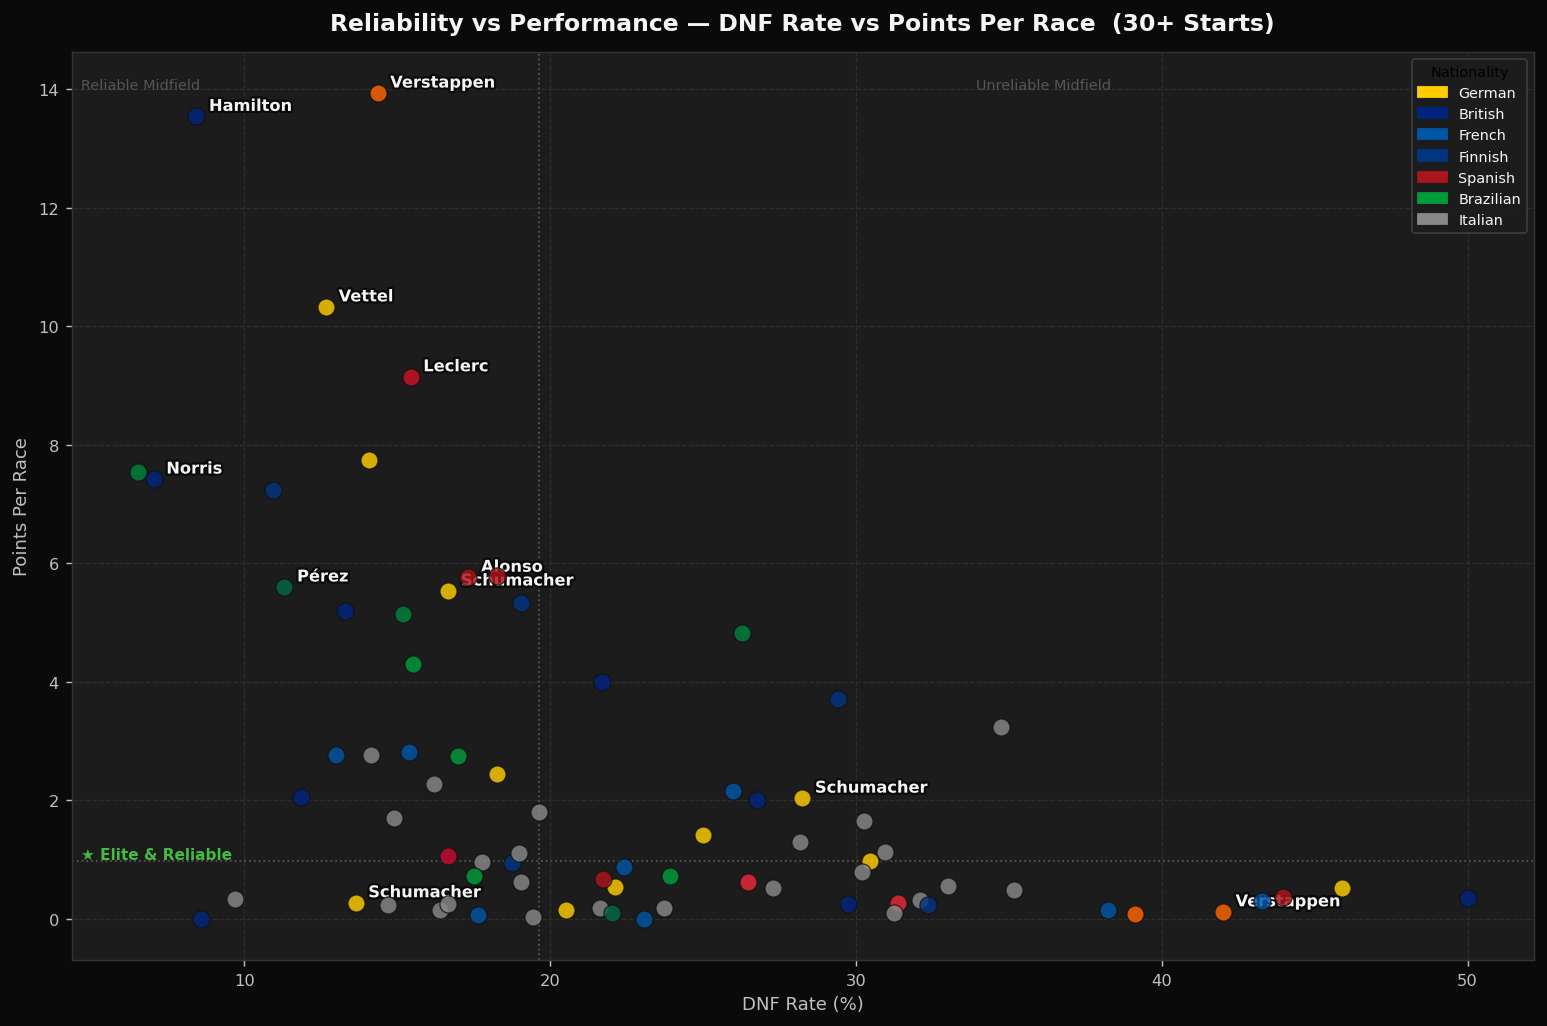

In [13]:
fig, ax = plt.subplots(figsize=(12, 8), facecolor=F1_DARK)
style_ax(ax, title='Reliability vs Performance — DNF Rate vs Points Per Race  (30+ Starts)',
         xlabel='DNF Rate (%)', ylabel='Points Per Race', grid=None)
ax.grid(color='#2E2E2E', lw=0.7, ls='--')

for _, row in d_30plus.iterrows():
    c = NAT_PALETTE.get(row['nationality'], '#888888')
    ax.scatter(row['dnf_rate_pct'], row['points_per_race'],
               color=c, s=90, alpha=0.82, edgecolors='#111', linewidths=0.7, zorder=5)

highlight2 = ['Hamilton', 'Verstappen', 'Vettel', 'Schumacher', 'Alonso',
              'Leclerc', 'Pérez', 'Norris']
for _, row in d_30plus.iterrows():
    if row['surname'] in highlight2:
        ax.annotate(row['surname'],
                    xy=(row['dnf_rate_pct'], row['points_per_race']),
                    xytext=(7, 3), textcoords='offset points',
                    color=F1_WHITE, fontsize=9, fontweight='bold',
                    path_effects=[pe.withStroke(linewidth=2.5, foreground=F1_DARK)])

med_dnf = d_30plus['dnf_rate_pct'].median()
med_ppr = d_30plus['points_per_race'].median()
ax.axvline(med_dnf, color='#555', lw=1, ls=':')
ax.axhline(med_ppr, color='#555', lw=1, ls=':')

xlim, ylim = ax.get_xlim(), ax.get_ylim()
ax.text(xlim[0]+0.3, ylim[1]*0.97, 'Reliable Midfield',  color='#555', fontsize=8, va='top')
ax.text(xlim[1]*0.65, ylim[1]*0.97, 'Unreliable Midfield', color='#555', fontsize=8, va='top')
ax.text(xlim[0]+0.3, med_ppr*1.05, '★ Elite & Reliable', color='#44BB44', fontsize=8.5, fontweight='bold')

nat_shown = d_30plus['nationality'].value_counts().head(7).index.tolist()
handles   = [mpatches.Patch(color=NAT_PALETTE.get(n,'#888'), label=n) for n in nat_shown]
ax.legend(handles=handles, title='Nationality', facecolor=F1_GREY, edgecolor='#444',
          labelcolor=F1_WHITE, fontsize=8, title_fontsize=8, loc='upper right')

fig.patch.set_facecolor(F1_DARK)
plt.tight_layout()
plt.show()

**📊 Insight**

**The elite zone is almost empty.** Drivers with points per race above 13 *and* DNF rate below 10% can be counted on one hand. Hamilton and Verstappen are its clearest occupants — both combine scoring dominance with exceptional mechanical survival rates, reflecting the quality of their machinery as much as their own driving discipline.

**The Alonso paradox.** His DNF rate (~17%) is the highest of any significant points-scorer in the dataset. This is not a driving style issue — it reflects McLaren Honda's catastrophic 2015–2017 reliability and Ferrari's mid-2010s fragility. Absent those mechanical failures, Alonso's point on this chart would shift sharply to the left.

**The diagonal structure is the key finding.** Faster drivers (higher points/race) systematically have lower DNF rates. This is not intuitive — aggressive driving should correlate with more retirements. What it actually reflects is that **team quality drives both dimensions simultaneously**: the best teams build the fastest cars *and* the most reliable ones. This makes it structurally very hard to close the gap to a dominant team from behind.

---
### 4.6 How Close Were the Title Fights?

**What:** Two panels — (left) WDC points margin between champion and runner-up each season; (right) number of races on the calendar per season.

**Why it matters:** Margin of victory reveals whether a title was a foregone conclusion or a genuine fight. Calendar size contextualises those margins — a 100-point gap in a 17-race season is structurally different from the same gap in a 24-race season.

**Hypothesis:** Narrow margins in 2007, 2008, 2010, 2021. Wide red bars in 2002–2004, 2011, 2013, 2023. Consistent upward calendar growth with a COVID dip in 2020.

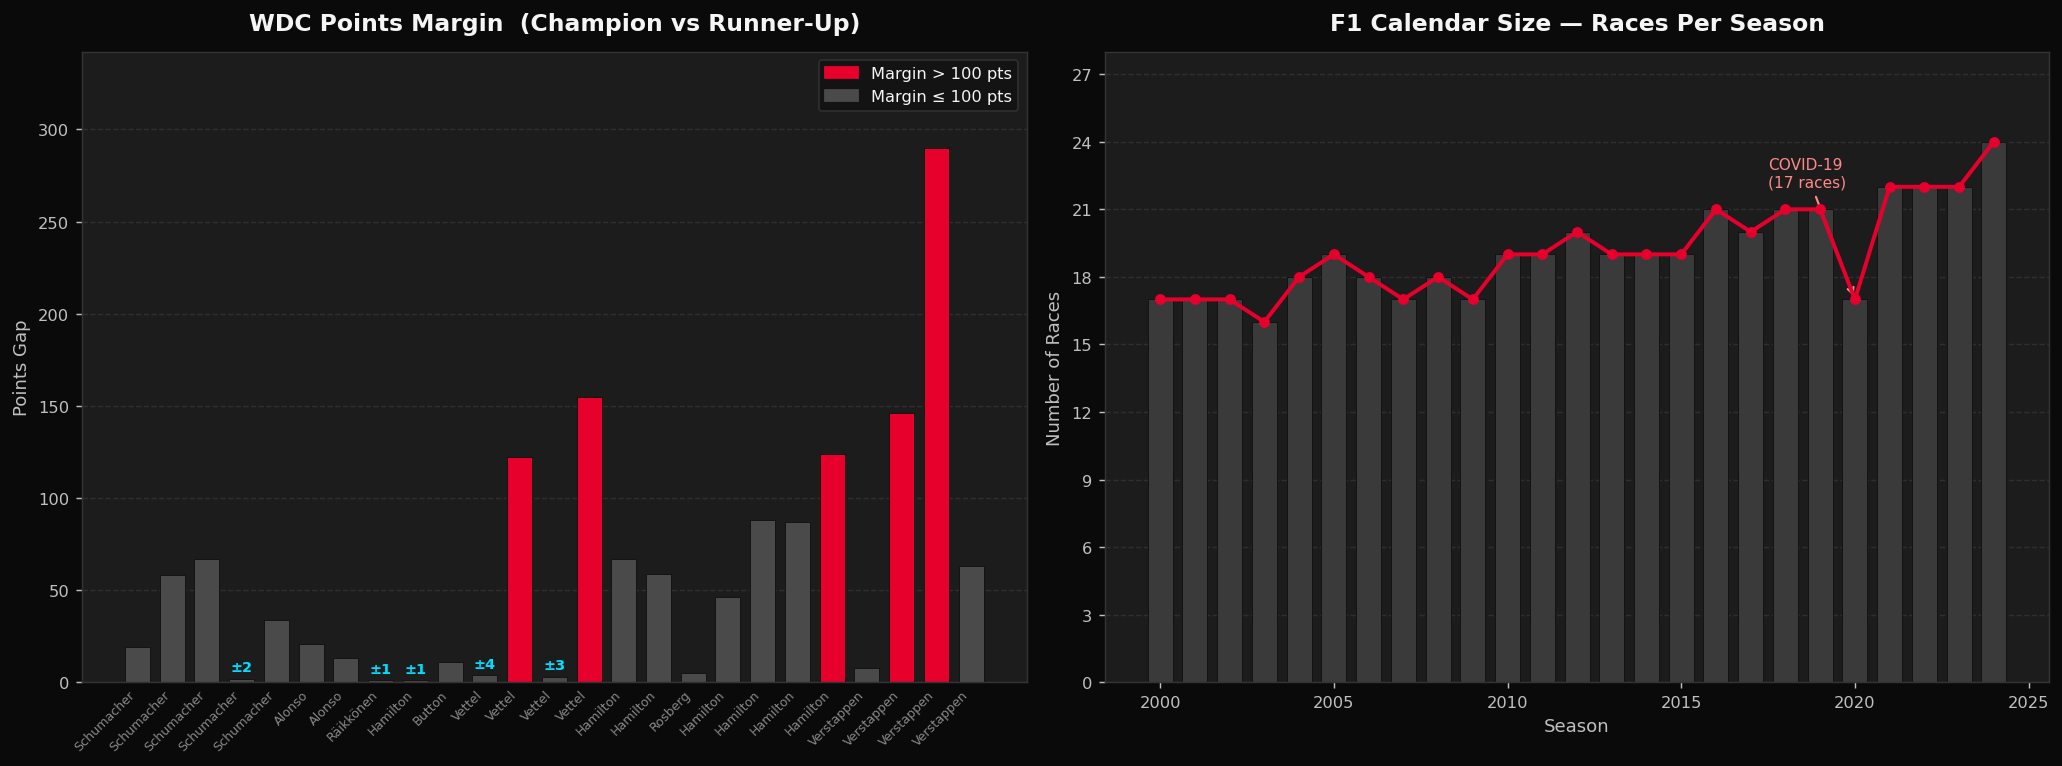

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=F1_DARK)
fig.patch.set_facecolor(F1_DARK)

# ── LEFT: WDC margin ─────────────────────────────────────────────────────────
ax = axes[0]
style_ax(ax, title='WDC Points Margin  (Champion vs Runner-Up)',
         xlabel='', ylabel='Points Gap')

bar_colors = [F1_RED if m > 100 else '#4A4A4A' for m in seasons['wdc_margin_pts']]
ax.bar(seasons['year'], seasons['wdc_margin_pts'],
       color=bar_colors, edgecolor='#111', lw=0.5, width=0.72)

# Annotate the five closest fights
for _, row in seasons.nsmallest(5, 'wdc_margin_pts').iterrows():
    ax.text(row['year'], row['wdc_margin_pts'] + 4, f"±{row['wdc_margin_pts']:.0f}",
            ha='center', color='#00DDFF', fontsize=8, fontweight='bold')

# FIX: champion surnames as x-tick labels (eliminates excessive blank space)
ax.set_xticks(seasons['year'])
ax.set_xticklabels([row['wdc_driver'].split()[-1] for _, row in seasons.iterrows()],
                   rotation=45, ha='right', color='#888', fontsize=7)
ax.tick_params(axis='x', length=0, pad=3)
ax.set_ylim(0, seasons['wdc_margin_pts'].max() * 1.18)

red_patch  = mpatches.Patch(color=F1_RED,    label='Margin > 100 pts')
grey_patch = mpatches.Patch(color='#4A4A4A', label='Margin ≤ 100 pts')
ax.legend(handles=[red_patch, grey_patch], facecolor='#111', edgecolor='#333',
          labelcolor=F1_WHITE, fontsize=9, loc='upper right')

# ── RIGHT: Calendar growth ────────────────────────────────────────────────────
ax2 = axes[1]
style_ax(ax2, title='F1 Calendar Size — Races Per Season',
         xlabel='Season', ylabel='Number of Races')

ax2.bar(seasons['year'], seasons['total_races'],
        color='#3A3A3A', edgecolor='#111', lw=0.5, width=0.72)
ax2.plot(seasons['year'], seasons['total_races'],
         color=F1_RED, lw=2.2, marker='o', markersize=5, zorder=5)

covid_row = seasons[seasons['year'] == 2020].iloc[0]
ax2.annotate('COVID-19\n(17 races)', xy=(2020, covid_row['total_races']),
             xytext=(2017.5, 22), color='#FF8888', fontsize=8.5,
             arrowprops=dict(arrowstyle='->', color='#FF8888', lw=1.2))

ax2.set_ylim(0, seasons['total_races'].max() + 4)
ax2.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

**📊 Insight**

**Genuine title fights are the exception.** Of 25 seasons, only **8 were decided by fewer than 20 points** — roughly one in three. Most championships were effectively resolved before the final race weekend.

The four closest finishes by margin:
- **2007 — 1 pt (Räikkönen):** Hamilton needed only to finish 5th in either of the last two races. He failed in both.
- **2008 — 1 pt (Hamilton):** Won on the final corner of the final lap in Brazil when Glock lost positions on worn intermediates.
- **2010 — 4 pts (Vettel):** Four drivers entered the finale with mathematical championship chances.
- **2021 — 8 pts (Verstappen):** The most sustained two-driver battle in a generation — resolved on the final lap under controversial Safety Car conditions.

**Calendar inflation is the confound most commentary ignores.** A 290-point margin (2023) in a 22-race season represents ~13 points per race of superiority. The same margin in a 17-race season would be structurally impossible — there aren't enough points available. Per-race normalisation is the only valid cross-season comparison.

---
### 4.7 Which Teams Built the Most Reliable Cars?

**What:** Heatmap — reliability rate (% of race entries that finished) per constructor per season, 2015–2024. Colour: red = low, green = high.

**Why it matters:** Reliability is a prerequisite for performance. The fastest car scores zero points from a retirement. This view separates teams whose championship ambitions were undermined by engineering fragility from those who combined speed with robustness.

**Hypothesis:** Mercedes near-perfect reliability throughout the hybrid era. Ferrari showing variance (known fragility years). Universal dip in 2022 (first year of ground-effect regulations). Red Bull near-perfect in 2023.

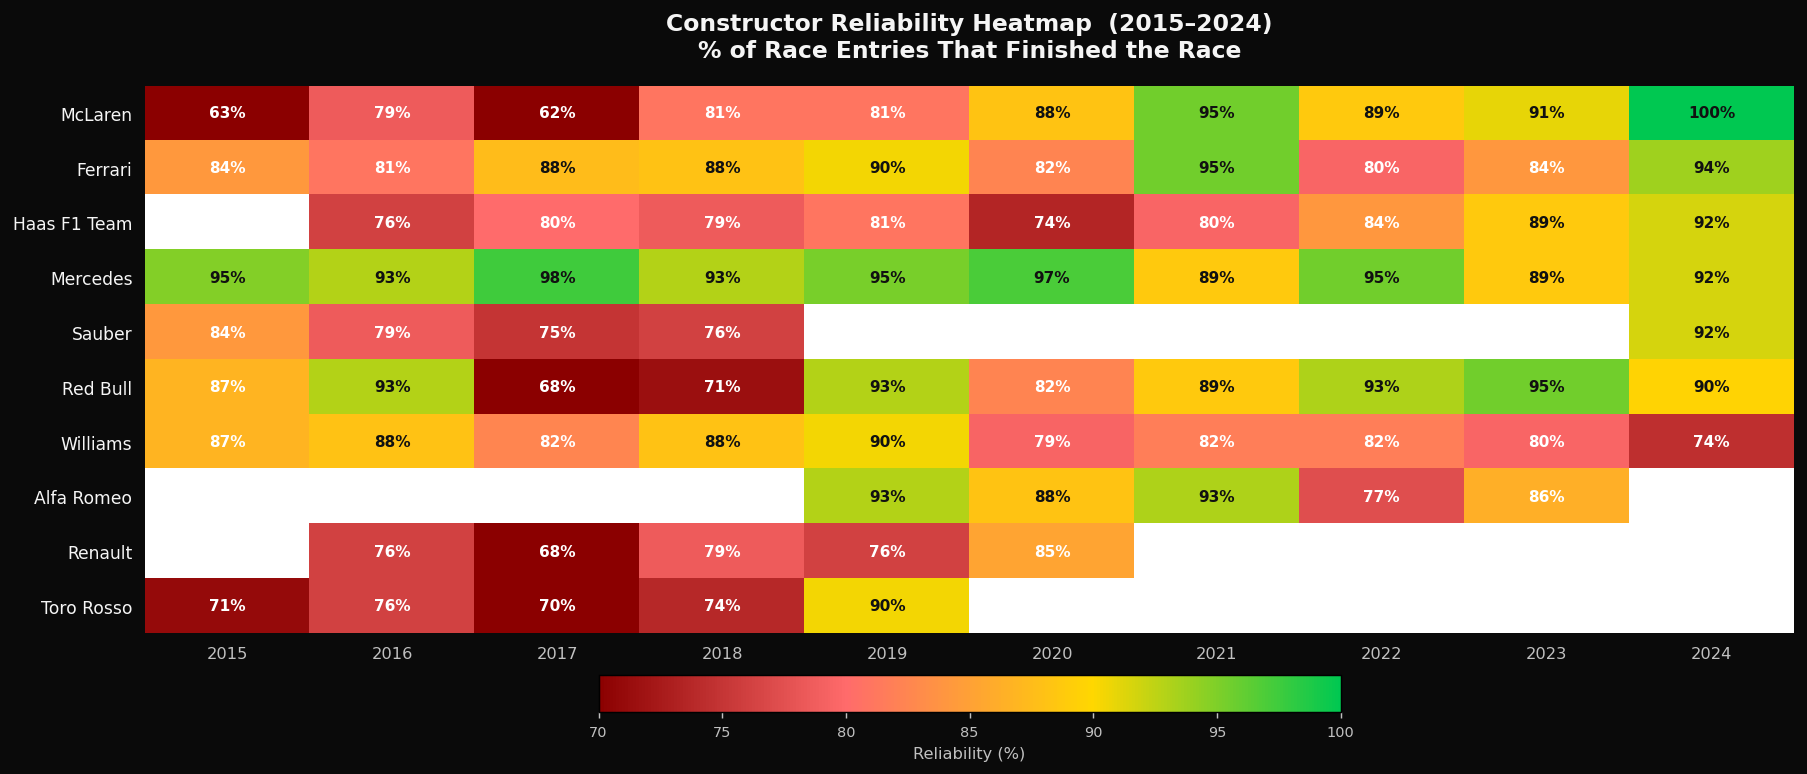

In [15]:
team_rel = teams[teams['year'] >= 2015].copy()
pivot = team_rel.pivot_table(index='name', columns='year',
                              values='reliability_pct', aggfunc='mean')
pivot = pivot.dropna(thresh=5).sort_values(by=pivot.columns[-1], ascending=False)

fig, ax = plt.subplots(figsize=(14, max(6, len(pivot) * 0.62)), facecolor=F1_DARK)
fig.patch.set_facecolor(F1_DARK)

cmap_rel = LinearSegmentedColormap.from_list('rel', ['#8B0000','#FF6B6B','#FFD700','#00C851'])
im = ax.imshow(pivot.values, cmap=cmap_rel, aspect='auto', vmin=70, vmax=100)

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([str(y) for y in pivot.columns], color=F1_SILVER, fontsize=9)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, color=F1_WHITE, fontsize=9.5)
ax.tick_params(left=False, bottom=False)
for spine in ax.spines.values():
    spine.set_visible(False)

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.0f}%', ha='center', va='center',
                    color='white' if val < 87 else '#111111',
                    fontsize=8.5, fontweight='bold')

ax.set_title('Constructor Reliability Heatmap  (2015–2024)\n'
             '% of Race Entries That Finished the Race',
             color=F1_WHITE, fontsize=13, fontweight='bold', pad=16)

cbar = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.06, shrink=0.45)
cbar.set_label('Reliability (%)', color=F1_SILVER, fontsize=9)
cbar.ax.xaxis.set_tick_params(color=F1_SILVER)
plt.setp(cbar.ax.xaxis.get_ticklabels(), color=F1_SILVER, fontsize=8)

plt.tight_layout()
plt.show()

**📊 Insight**

**Mercedes set the benchmark.** Consistently 90%+ throughout the hybrid era while simultaneously running the fastest car on the grid — a combination that requires extraordinary engineering discipline. Usually, chasing performance pushes teams toward reliability limits. Mercedes avoided that trade-off for eight consecutive years.

**Ferrari's variance is the dataset's most consequential story.** Their reliability scores show the highest variance of any team in the heatmap. The compounding effect of retirements across multiple competitive seasons represents championship points that cannot be recovered — the data's most precise explanation of why Ferrari's pace often exceeded their WCC standings.

**2022 was a universal stress test.** Almost every team shows a reliability dip in the 2022 column — the first year of ground-effect regulations. New architectures encountering real race stresses for the first time produce failure modes that no amount of simulation fully anticipates.

**Red Bull 2023:** 95%+ reliability combined with 21 wins out of 22 races. Speed and reliability simultaneously maximised — the rarest and most dominant combination in competitive sport.

---
## 5. Conclusions & Strategic Takeaways

Seven questions. Seven answers. Below is the synthesis — what the data actually says about 25 years of Formula 1.

---

<div style="background:#111;border-left:5px solid #E8002D;padding:18px 22px;border-radius:10px;margin:16px 0;">

### 🏆 Finding 1: Hamilton Leads by Volume — Verstappen Leads by Rate

4,820 points, 105 wins, 202 podiums across 18 seasons — Hamilton's career totals are the greatest in the modern era. But Verstappen scores at **13.9 pts/race vs Hamilton's 13.5**, with a near-identical win rate achieved in half the career length. Raw totals reward longevity; per-race metrics reveal near-parity. The debate is not resolved by this data — it is complicated by it.

</div>

<div style="background:#111;border-left:5px solid #3671C6;padding:18px 22px;border-radius:10px;margin:16px 0;">

### 📉 Finding 2: Dominance Is Structural, Not Personal

Each of the three modern dynasties — Ferrari (2000–04), Red Bull (2010–13), Mercedes (2014–21) — was built on a **specific, regulation-bounded technical advantage**. Each collapsed when that advantage was regulated away or countered. No dynasty survived a major technical reset intact. Attributing these periods of dominance to individual brilliance understates the role of the regulatory environment.

</div>

<div style="background:#111;border-left:5px solid #00D2BE;padding:18px 22px;border-radius:10px;margin:16px 0;">

### ⚖️ Finding 3: Real Competitiveness Is Rarer Than Memory Suggests

Only **8 of 25 seasons** were decided by fewer than 20 points. The sport's narrative of annual nail-biters is built on a small number of exceptional seasons — 2007, 2008, 2010, 2012, 2021 — that occupy disproportionate cultural space. The median HHI of 0.33 confirms the sport is structurally biased toward moderate-to-high dominance.

</div>

<div style="background:#111;border-left:5px solid #FF8000;padding:18px 22px;border-radius:10px;margin:16px 0;">

### 🔧 Finding 4: Reliability Is a Championship Prerequisite

Every constructor dynasty in this dataset was simultaneously dominant *and* reliable. The correlation is not coincidental — the same engineering organisations that build the fastest cars build the most durable ones. Ferrari's reliability failures during competitive car phases are the clearest counter-example: pace without reliability produces podiums but rarely championships.

</div>

<div style="background:#111;border-left:5px solid #C0C0C0;padding:18px 22px;border-radius:10px;margin:16px 0;">

### 📅 Finding 5: Per-Race Normalisation Is Analytically Mandatory

The calendar grew from 16 races (2003) to 24 races (2024) — 50% more scoring opportunities. Raw career totals systematically favour recent-era drivers. Any cross-era comparison based on total wins or total points is confounded by calendar size. **Win rate, podium rate, and points per race are the only valid cross-era metrics.**

</div>

---

### 💡 Methodological Takeaways

1. **Normalise for opportunity.** Rate metrics (per race, per season) are always more comparable than raw counts across different sample sizes.
2. **Borrow from adjacent fields.** The HHI — an economics tool — is more rigorous than any competition metric native to F1 statistics.
3. **Context is the variable.** The most important variable in any driver's statistics is the car they were given. Analysis that ignores team-level performance is incomplete.
4. **Outliers carry information.** Alonso's high DNF rate in a strong-points-per-race career is more analytically valuable than Hamilton's clean chart position — because it reveals the structural inequalities of the sport.

---

### 🔭 Extensions Worth Pursuing

- **Qualifying vs race delta** — which drivers gained the most positions from grid to finish?
- **Teammate comparison** — the cleanest isolation of driver talent: same car, same season, direct head-to-head
- **Circuit-specific performance** — which drivers/teams systematically over- or underperformed at specific tracks?
- **Pit stop strategy modelling** — using stop timing data to separate strategic advantage from mechanical advantage

---
## 6. Executive Summary

*This section presents the analysis findings as a concise stakeholder briefing — key takeaways without analytical detail, suitable for a non-technical audience or a portfolio one-pager.*

---

<div style="background:#0d0d0d;border:1px solid #2a2a2a;border-radius:14px;padding:32px 36px;margin:8px 0;">

<h3 style="color:#E8002D;margin:0 0 6px 0;font-size:1.1em;letter-spacing:1px;text-transform:uppercase;">Formula 1 · 2000–2024 · Key Findings</h3>
<p style="color:#666;font-size:.85em;margin:0 0 28px 0;">Based on 479 races · 117 drivers · 14 source tables</p>

<table style="width:100%;border-collapse:collapse;">
  <tr style="border-bottom:1px solid #1e1e1e;">
    <td style="padding:14px 0;width:36px;vertical-align:top;font-size:1.3em;">🏆</td>
    <td style="padding:14px 16px 14px 0;vertical-align:top;">
      <strong style="color:#fff;">Lewis Hamilton is the modern era's greatest driver by volume — but Max Verstappen is scoring faster.</strong>
      <br/><span style="color:#888;font-size:.9em;">Hamilton: 4,820 pts · 105 wins · 18 seasons. Verstappen: 13.9 pts/race vs Hamilton's 13.5, comparable win rate in half the career length.</span>
    </td>
  </tr>
  <tr style="border-bottom:1px solid #1e1e1e;">
    <td style="padding:14px 0;vertical-align:top;font-size:1.3em;">📉</td>
    <td style="padding:14px 16px 14px 0;vertical-align:top;">
      <strong style="color:#fff;">Every dominant era ended when regulations changed — not when rivals simply caught up.</strong>
      <br/><span style="color:#888;font-size:.9em;">Ferrari (2000–04), Red Bull (2010–13), and Mercedes (2014–21) each lost their advantage at a regulation reset, not through natural competitive equalisation.</span>
    </td>
  </tr>
  <tr style="border-bottom:1px solid #1e1e1e;">
    <td style="padding:14px 0;vertical-align:top;font-size:1.3em;">⚡</td>
    <td style="padding:14px 16px 14px 0;vertical-align:top;">
      <strong style="color:#fff;">2023 was the most statistically dominant season since records began — surpassing even Schumacher's peak.</strong>
      <br/><span style="color:#888;font-size:.9em;">Verstappen's HHI of 0.76 (21/22 wins, 290-pt margin) exceeds Schumacher's 2004 peak of 0.54 by a wide margin. By economic standards, 2023 was a monopoly.</span>
    </td>
  </tr>
  <tr style="border-bottom:1px solid #1e1e1e;">
    <td style="padding:14px 0;vertical-align:top;font-size:1.3em;">⚖️</td>
    <td style="padding:14px 16px 14px 0;vertical-align:top;">
      <strong style="color:#fff;">Only 8 of 25 seasons were genuinely close — F1's competitive narrative is built on exceptions.</strong>
      <br/><span style="color:#888;font-size:.9em;">Just 4 seasons were decided by fewer than 5 points (2007, 2008, 2010, 2012). The median championship margin is over 50 points.</span>
    </td>
  </tr>
  <tr style="border-bottom:1px solid #1e1e1e;">
    <td style="padding:14px 0;vertical-align:top;font-size:1.3em;">🔧</td>
    <td style="padding:14px 16px 14px 0;vertical-align:top;">
      <strong style="color:#fff;">Reliability and speed are not a trade-off — the fastest teams are also the most reliable.</strong>
      <br/><span style="color:#888;font-size:.9em;">Mercedes averaged 95%+ reliability throughout their 8-title hybrid era while leading on pace. Ferrari's reliability failures in competitive years represent a quantifiable championship opportunity cost.</span>
    </td>
  </tr>
  <tr style="border-bottom:1px solid #1e1e1e;">
    <td style="padding:14px 0;vertical-align:top;font-size:1.3em;">📅</td>
    <td style="padding:14px 16px 14px 0;vertical-align:top;">
      <strong style="color:#fff;">A 50% calendar expansion since 2003 makes raw statistics misleading across eras.</strong>
      <br/><span style="color:#888;font-size:.9em;">16 races in 2003 → 24 in 2024. Any comparison of total wins or points across seasons requires per-race normalisation to be analytically valid.</span>
    </td>
  </tr>
  <tr>
    <td style="padding:14px 0;vertical-align:top;font-size:1.3em;">🏎️</td>
    <td style="padding:14px 16px 14px 0;vertical-align:top;">
      <strong style="color:#fff;">2012 was the most genuinely competitive season in the modern era.</strong>
      <br/><span style="color:#888;font-size:.9em;">HHI of 0.165 — the dataset's minimum. Seven different winners in the first seven races. Championship decided on the final lap of the final race by 3 points.</span>
    </td>
  </tr>
</table>

<hr style="border:none;border-top:1px solid #1e1e1e;margin:28px 0 20px 0;"/>

<p style="color:#555;font-size:.8em;margin:0;line-height:1.6;">
  <strong style="color:#666;">Pipeline:</strong> ingestion → cleaning → transformation → mart construction · 
  <strong style="color:#666;">Source:</strong> Ergast Motor Racing API · 
  <strong style="color:#666;">Tools:</strong> Python 3.12 · pandas · matplotlib · seaborn · numpy
</p>

</div>